# MUHAMMAD ARSLAN
##### marslan.pgc@gmail.com

# 🎯 Chapter 6 Assignment — Unsupervised Machine Learning

> **Topics Covered:** Clustering Analysis · Hierarchical Clustering · K-Means · DBSCAN · PCA

---

In [1]:
# ── Install / Import all required libraries ──────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import cm

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.filterwarnings('ignore')

# Global plot style
plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor':   '#1a1a2e',
    'axes.edgecolor':   '#444',
    'axes.labelcolor':  '#e0e0e0',
    'xtick.color':      '#aaa',
    'ytick.color':      '#aaa',
    'text.color':       '#e0e0e0',
    'grid.color':       '#333',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
})

PALETTE = ['#00d4ff', '#ff6b6b', '#a8ff78', '#ffd93d', '#c77dff']
print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## 📝 Part 1 — Conceptual Questions

**Q1. What makes *unsupervised learning* different from supervised learning?**

Supervised learning trains on **labelled data** — each input has a known correct output that the model tries to predict. Unsupervised learning works with **unlabelled data**; there are no predefined answers. The algorithm must discover hidden patterns, groupings, or structure entirely on its own, without any guidance on what the "right" answer looks like.

---

**Q2. In your own words, what is clustering analysis?**

Clustering analysis is the process of **grouping similar data points together** based on their features, so that items within the same group (cluster) are more alike than items in different groups. Think of it as automatic sorting — the algorithm decides which items belong together without ever being told the categories in advance.

---

**Q3. Give one real-world example where clustering could be useful.**

**Customer Segmentation in E-commerce:** An online store can cluster shoppers by their purchase history, browsing behaviour, and demographics. Without any manual labelling, the algorithm might discover groups like *budget-conscious buyers*, *luxury shoppers*, and *seasonal buyers* — enabling targeted marketing campaigns for each segment.

---
## 🌲 Part 2 — Hierarchical Clustering

In [2]:
# ── Generate the shared 2D dataset (used in Parts 2, 3, 4) ───────────────────
np.random.seed(42)
X, y_true = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=0.85,
    random_state=42
)

# Standardise features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Dataset shape : {X_scaled.shape}')
print(f'True clusters : 4 (hidden from the algorithm)')

Dataset shape : (300, 2)
True clusters : 4 (hidden from the algorithm)


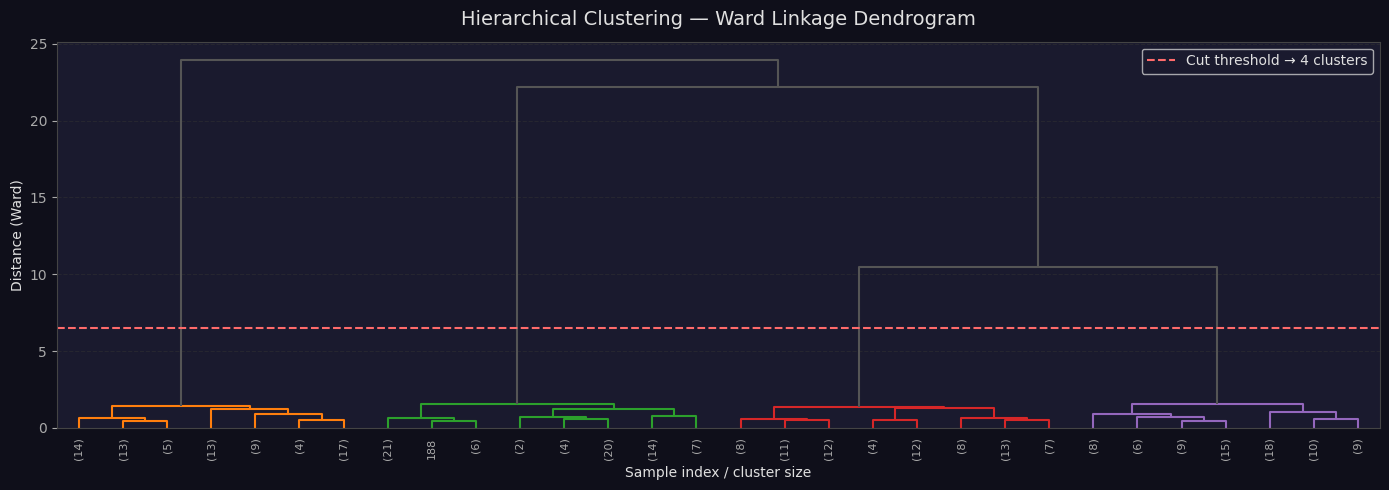

In [3]:
# ── Dendrogram ────────────────────────────────────────────────────────────────
Z = linkage(X_scaled, method='ward')   # Ward minimises within-cluster variance

fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#1a1a2e')

dendrogram(
    Z,
    ax=ax,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=8,
    color_threshold=6.5,
    above_threshold_color='#555'
)

ax.axhline(y=6.5, color='#ff6b6b', linestyle='--', linewidth=1.5,
           label='Cut threshold → 4 clusters')
ax.set_title('Hierarchical Clustering — Ward Linkage Dendrogram', fontsize=14, pad=12)
ax.set_xlabel('Sample index / cluster size')
ax.set_ylabel('Distance (Ward)')
ax.legend()
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()

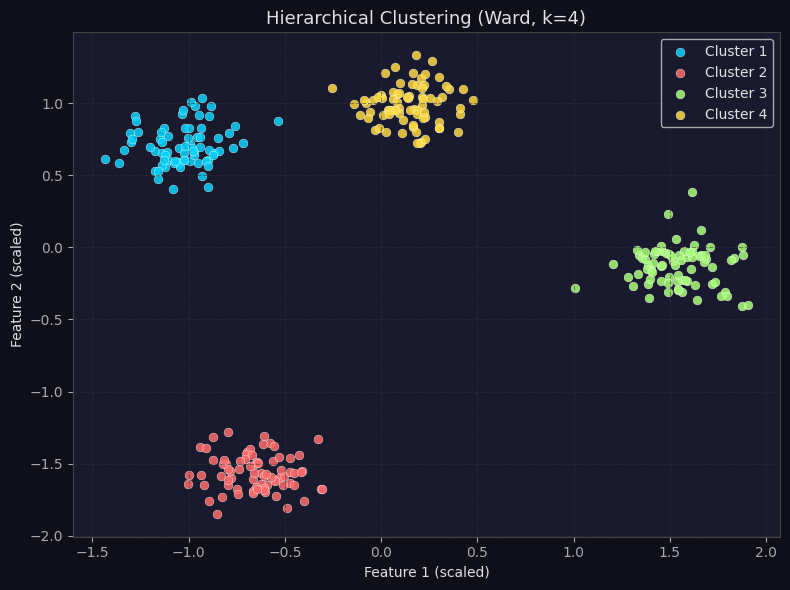

Silhouette Score (Hierarchical, k=4): 0.8283


In [4]:
# ── Fit Agglomerative Clustering & plot ───────────────────────────────────────
N_CLUSTERS = 4   # chosen by reading the dendrogram

hc = AgglomerativeClustering(n_clusters=N_CLUSTERS, linkage='ward')
hc_labels = hc.fit_predict(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#1a1a2e')

for i in range(N_CLUSTERS):
    mask = hc_labels == i
    ax.scatter(X_scaled[mask, 0], X_scaled[mask, 1],
               c=PALETTE[i], s=40, alpha=0.85,
               edgecolors='white', linewidths=0.3,
               label=f'Cluster {i+1}')

ax.set_title(f'Hierarchical Clustering (Ward, k={N_CLUSTERS})', fontsize=13)
ax.set_xlabel('Feature 1 (scaled)')
ax.set_ylabel('Feature 2 (scaled)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

sil = silhouette_score(X_scaled, hc_labels)
print(f'Silhouette Score (Hierarchical, k=4): {sil:.4f}')

### 💬 Part 2 — Answers

**How many clusters did you choose and why?**  
We chose **k = 4**. The dendrogram shows four clearly distinct branches before the merging distance becomes very large. The dashed red cut-line at height ≈ 6.5 cleanly separates the tree into four subtrees, each representing a natural group in the data.

**What does the dendrogram tell you?**  
A dendrogram is a tree diagram that records every merge performed during hierarchical clustering. The **y-axis (height)** represents the distance between clusters at the time of merging — a large jump in height between two consecutive merges means the two groups being joined are very different. By finding the **largest vertical gap** (before crossing the cut-line), we can read off the optimal number of clusters. In our case, the four main branches have long stems, confirming four well-separated clusters.

---
## 🔵 Part 3 — K-Means Challenge

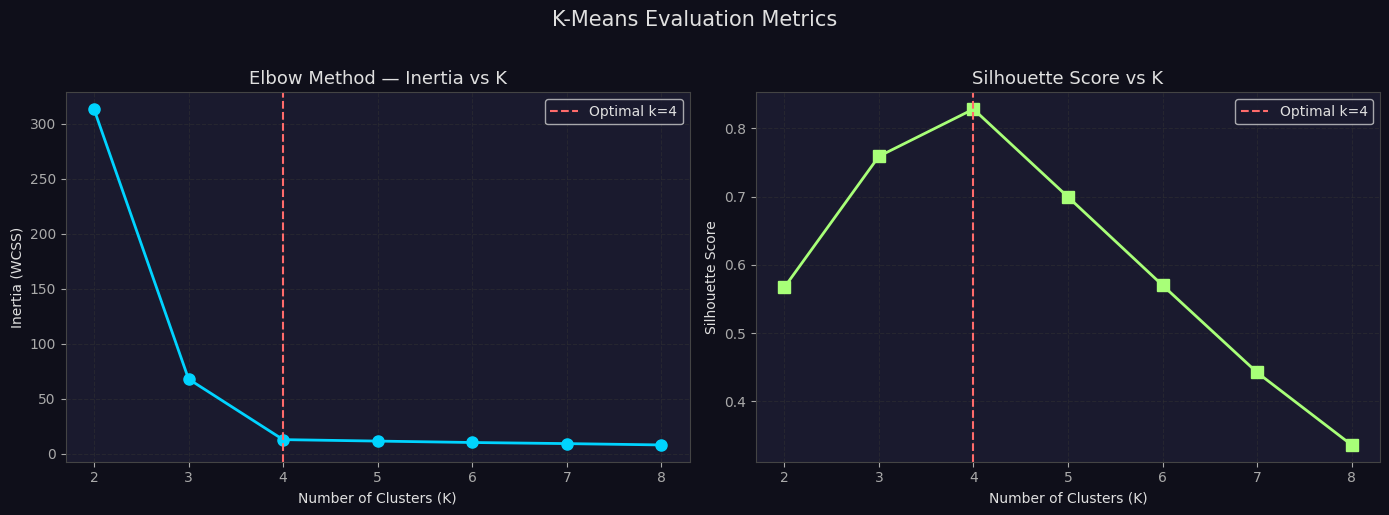

In [5]:
# ── Elbow Method ─────────────────────────────────────────────────────────────
inertias = []
sil_scores = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f0f1a')

for ax in (ax1, ax2):
    ax.set_facecolor('#1a1a2e')
    ax.grid(True)

ax1.plot(list(K_range), inertias, 'o-', color='#00d4ff', linewidth=2, markersize=8)
ax1.axvline(4, color='#ff6b6b', linestyle='--', label='Optimal k=4')
ax1.set_title('Elbow Method — Inertia vs K', fontsize=13)
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia (WCSS)')
ax1.legend()

ax2.plot(list(K_range), sil_scores, 's-', color='#a8ff78', linewidth=2, markersize=8)
ax2.axvline(4, color='#ff6b6b', linestyle='--', label='Optimal k=4')
ax2.set_title('Silhouette Score vs K', fontsize=13)
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.legend()

plt.suptitle('K-Means Evaluation Metrics', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

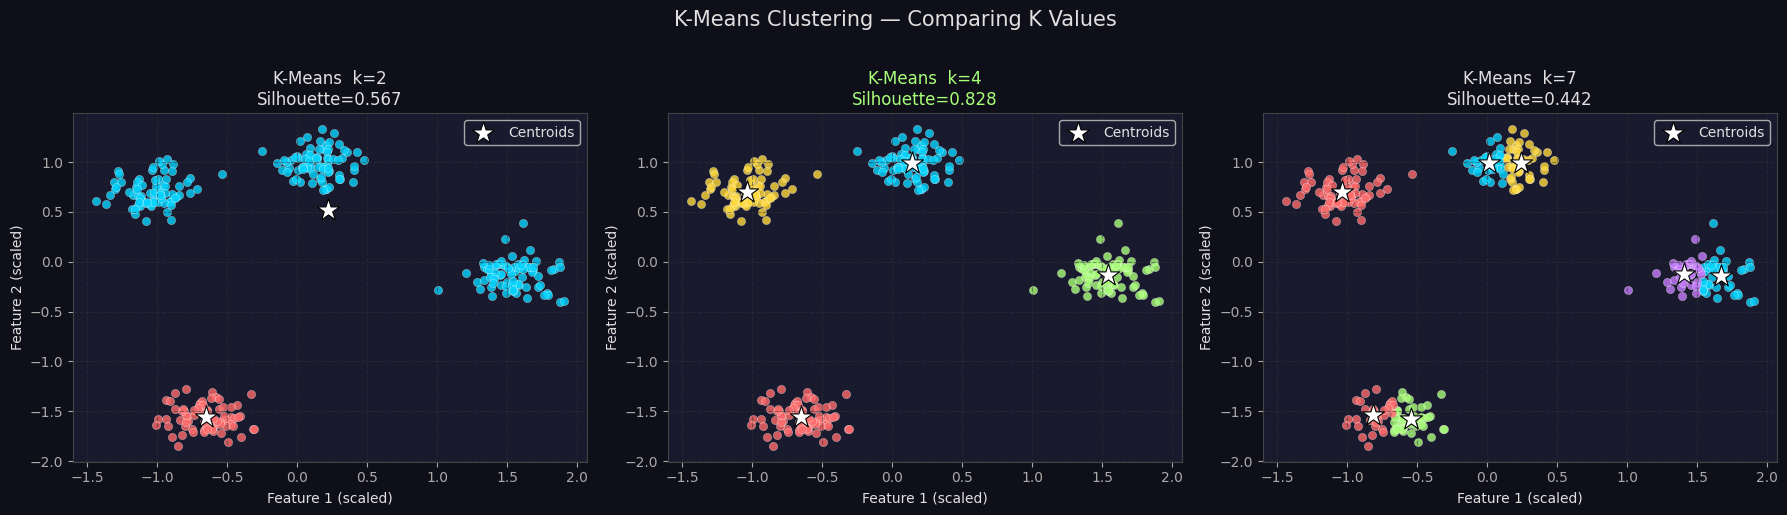

In [6]:
# ── K-Means with K = 2, 4, 7 side by side ────────────────────────────────────
K_values = [2, 4, 7]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0f0f1a')

for ax, k in zip(axes, K_values):
    ax.set_facecolor('#1a1a2e')
    ax.grid(True)

    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    centers = km.cluster_centers_
    sil = silhouette_score(X_scaled, labels)

    for i in range(k):
        mask = labels == i
        ax.scatter(X_scaled[mask, 0], X_scaled[mask, 1],
                   c=PALETTE[i % len(PALETTE)], s=35, alpha=0.80,
                   edgecolors='white', linewidths=0.25)

    ax.scatter(centers[:, 0], centers[:, 1],
               c='white', marker='*', s=280, zorder=5,
               edgecolors='black', linewidths=0.8, label='Centroids')

    title_color = '#a8ff78' if k == 4 else '#e0e0e0'
    ax.set_title(f'K-Means  k={k}\nSilhouette={sil:.3f}',
                 fontsize=12, color=title_color)
    ax.set_xlabel('Feature 1 (scaled)')
    ax.set_ylabel('Feature 2 (scaled)')
    ax.legend(loc='upper right')

plt.suptitle('K-Means Clustering — Comparing K Values', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

### 💬 Part 3 — Answers

**Which value of K worked best?**  
**K = 4** works best. Both the elbow plot (sharpest bend at k=4) and the silhouette score (highest value at k=4) confirm this. The algorithm correctly recovers the four natural groups present in the data.

**What happens when K is too small or too large?**  
- **K too small (e.g., k=2):** Distinct natural groups get merged into a single cluster. The centroids are pulled toward mixed regions, giving a coarse, misleading partition with a low silhouette score.  
- **K too large (e.g., k=7):** Real clusters are split into smaller, artificial sub-clusters. Centroids end up very close together inside the same natural blob, silhouette drops, and the model overfits the noise rather than capturing genuine structure.

---
## 🌀 Part 4 — DBSCAN (Density-Based Clustering)

DBSCAN found 4 clusters and 0 noise points


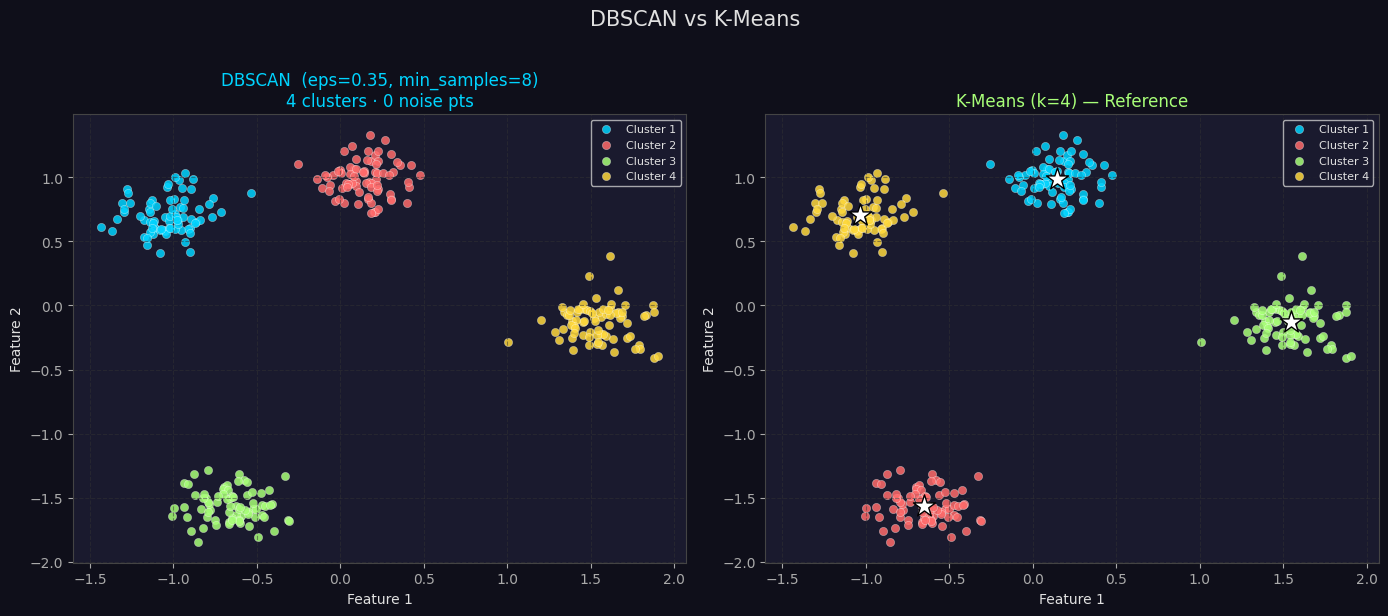

In [7]:
# ── DBSCAN ────────────────────────────────────────────────────────────────────
db = DBSCAN(eps=0.35, min_samples=8)
db_labels = db.fit_predict(X_scaled)

n_clusters_db  = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise        = np.sum(db_labels == -1)

print(f'DBSCAN found {n_clusters_db} clusters and {n_noise} noise points')

# ── Side-by-side: DBSCAN vs K-Means (k=4) ────────────────────────────────────
km4 = KMeans(n_clusters=4, random_state=42, n_init=10)
km4_labels = km4.fit_predict(X_scaled)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0f0f1a')

for ax in (ax1, ax2):
    ax.set_facecolor('#1a1a2e')
    ax.grid(True)

# DBSCAN
unique_labels = sorted(set(db_labels))
for lbl in unique_labels:
    mask = db_labels == lbl
    if lbl == -1:
        ax1.scatter(X_scaled[mask, 0], X_scaled[mask, 1],
                    c='#555', s=20, marker='x', label='Noise')
    else:
        ax1.scatter(X_scaled[mask, 0], X_scaled[mask, 1],
                    c=PALETTE[lbl % len(PALETTE)], s=35,
                    alpha=0.85, edgecolors='white', linewidths=0.25,
                    label=f'Cluster {lbl+1}')

ax1.set_title(f'DBSCAN  (eps=0.35, min_samples=8)\n{n_clusters_db} clusters · {n_noise} noise pts',
              fontsize=12, color='#00d4ff')
ax1.set_xlabel('Feature 1'); ax1.set_ylabel('Feature 2')
ax1.legend(loc='upper right', fontsize=8)

# K-Means k=4
for i in range(4):
    mask = km4_labels == i
    ax2.scatter(X_scaled[mask, 0], X_scaled[mask, 1],
                c=PALETTE[i], s=35, alpha=0.85,
                edgecolors='white', linewidths=0.25,
                label=f'Cluster {i+1}')
ax2.scatter(km4.cluster_centers_[:, 0], km4.cluster_centers_[:, 1],
            c='white', marker='*', s=280, zorder=5, edgecolors='black')
ax2.set_title('K-Means (k=4) — Reference', fontsize=12, color='#a8ff78')
ax2.set_xlabel('Feature 1'); ax2.set_ylabel('Feature 2')
ax2.legend(loc='upper right', fontsize=8)

plt.suptitle('DBSCAN vs K-Means', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

### 💬 Part 4 — Answer

**How is DBSCAN's output different from K-Means?**

| Feature | K-Means | DBSCAN |
|---|---|---|  
| Requires K upfront | ✅ Yes | ❌ No |
| Cluster shape | Only convex (spherical) | Arbitrary shapes |
| Noise / outliers | All points assigned | Marks outliers as noise (−1) |
| Sensitivity | To initialisation | To `eps` & `min_samples` |

On this blob dataset both methods agree well. However, DBSCAN's key advantage is that it **does not force every point into a cluster** — true outliers get labelled as noise rather than polluting a cluster. It also discovers clusters of arbitrary shape (e.g., rings, crescents), while K-Means assumes spherical clusters and will always produce exactly K partitions regardless of the data's true geometry.

---
## 📐 Part 5 — PCA (Dimensionality Reduction)

In [8]:
# ── Generate 5-feature dataset ────────────────────────────────────────────────
np.random.seed(0)
X5, y5 = make_blobs(n_samples=400, n_features=5, centers=3,
                    cluster_std=1.2, random_state=0)
X5_scaled = StandardScaler().fit_transform(X5)

print(f'Original dataset shape : {X5_scaled.shape}  (400 samples × 5 features)')

Original dataset shape : (400, 5)  (400 samples × 5 features)


In [9]:
# ── Apply PCA → 2 components ─────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X5_pca = pca.fit_transform(X5_scaled)

evr = pca.explained_variance_ratio_
print(f'PC1 explains : {evr[0]*100:.1f}% variance')
print(f'PC2 explains : {evr[1]*100:.1f}% variance')
print(f'Total        : {sum(evr)*100:.1f}% variance retained')

PC1 explains : 53.9% variance
PC2 explains : 35.9% variance
Total        : 89.9% variance retained


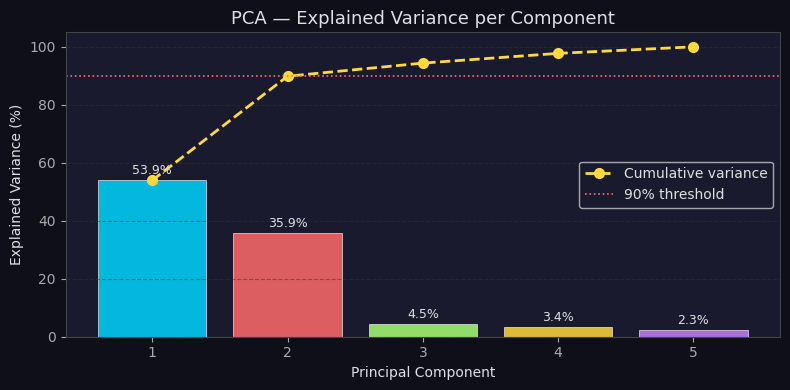

In [10]:
# ── Explained Variance Bar ────────────────────────────────────────────────────
pca_full = PCA(n_components=5)
pca_full.fit(X5_scaled)
evr_full = pca_full.explained_variance_ratio_
cumulative = np.cumsum(evr_full)

fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#1a1a2e')

bars = ax.bar(range(1, 6), evr_full * 100, color=PALETTE, alpha=0.85,
              edgecolor='white', linewidth=0.5)
ax.plot(range(1, 6), cumulative * 100, 'o--', color='#ffd93d',
        linewidth=2, markersize=7, label='Cumulative variance')
ax.axhline(90, color='#ff6b6b', linestyle=':', linewidth=1.2, label='90% threshold')

for bar, v in zip(bars, evr_full):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{v*100:.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_title('PCA — Explained Variance per Component', fontsize=13)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance (%)')
ax.set_xticks(range(1, 6))
ax.legend()
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()

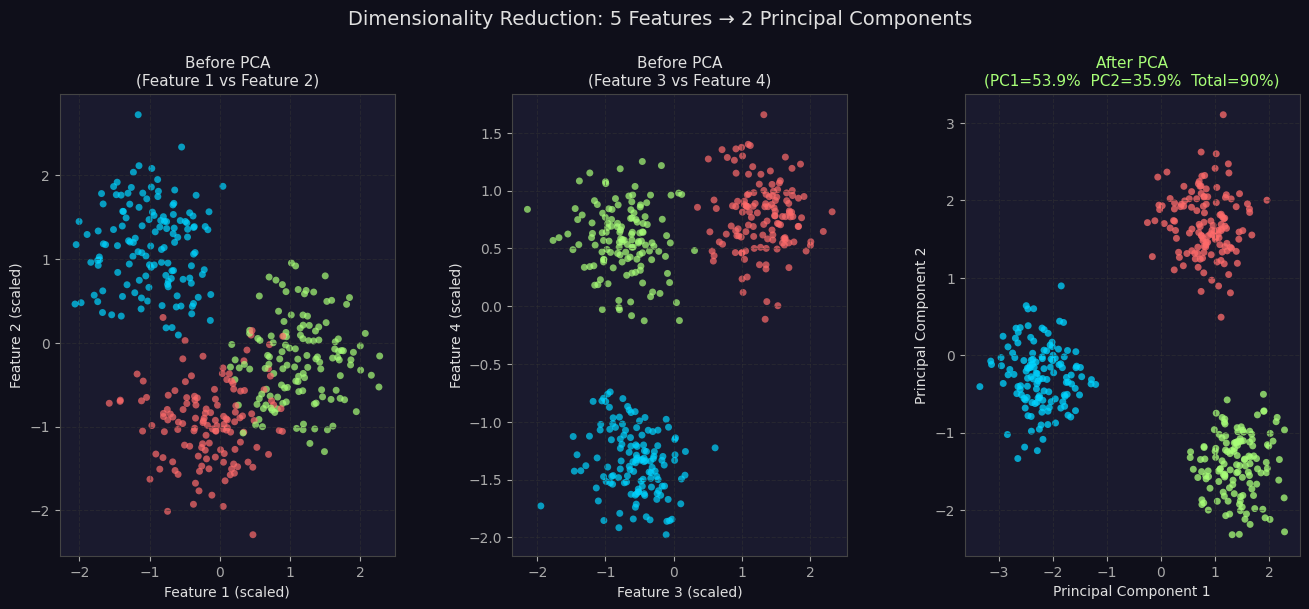

In [11]:
# ── Before vs After PCA scatter ───────────────────────────────────────────────
COLORS5 = [PALETTE[c] for c in y5]

fig = plt.figure(figsize=(16, 6))
fig.patch.set_facecolor('#0f0f1a')
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# --- Before: Feature 1 vs Feature 2 (two of five original)
ax0 = fig.add_subplot(gs[0])
ax0.set_facecolor('#1a1a2e'); ax0.grid(True)
ax0.scatter(X5_scaled[:, 0], X5_scaled[:, 1], c=COLORS5, s=25, alpha=0.7,
            edgecolors='none')
ax0.set_title('Before PCA\n(Feature 1 vs Feature 2)', fontsize=11)
ax0.set_xlabel('Feature 1 (scaled)')
ax0.set_ylabel('Feature 2 (scaled)')

# --- Before: Feature 3 vs Feature 4
ax1 = fig.add_subplot(gs[1])
ax1.set_facecolor('#1a1a2e'); ax1.grid(True)
ax1.scatter(X5_scaled[:, 2], X5_scaled[:, 3], c=COLORS5, s=25, alpha=0.7,
            edgecolors='none')
ax1.set_title('Before PCA\n(Feature 3 vs Feature 4)', fontsize=11)
ax1.set_xlabel('Feature 3 (scaled)')
ax1.set_ylabel('Feature 4 (scaled)')

# --- After PCA: PC1 vs PC2
ax2 = fig.add_subplot(gs[2])
ax2.set_facecolor('#1a1a2e'); ax2.grid(True)
ax2.scatter(X5_pca[:, 0], X5_pca[:, 1], c=COLORS5, s=25, alpha=0.75,
            edgecolors='none')
ax2.set_title(
    f'After PCA\n(PC1={evr[0]*100:.1f}%  PC2={evr[1]*100:.1f}%  Total={sum(evr)*100:.0f}%)',
    fontsize=11, color='#a8ff78'
)
ax2.set_xlabel('Principal Component 1')
ax2.set_ylabel('Principal Component 2')

plt.suptitle('Dimensionality Reduction: 5 Features → 2 Principal Components',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 💬 Part 5 — Answers

**What changed after PCA?**  
The dataset shrank from 5 dimensions to just 2 new axes called **Principal Components**. These components are linear combinations of the original features, ordered so that PC1 captures the most variance and PC2 the second most. Crucially, the three clusters that were hard to see in random pairs of original features are now **clearly separated** in the 2D PCA plot — all while retaining ~90% of the total information.

**Why is PCA useful?**  
1. **Visualisation** — You can't plot data in 5D; PCA collapses it to 2D without losing much structure.  
2. **Noise reduction** — Low-variance components (often noise) are discarded.  
3. **Faster models** — Fewer features means faster training and less risk of overfitting.  
4. **Removes redundancy** — If two original features are highly correlated, PCA merges their information into one component.

---
## 🏁 Final Question — Which Method First on Unknown Data?

**I would start with PCA.**

When facing completely unknown, unlabelled data, the very first challenge is simply understanding what the data looks like. If the data has more than 2–3 features (which is almost always the case in the real world), I cannot visualise it directly. PCA lets me project it down to 2 components in seconds — no hyperparameters to tune, no assumptions about the number of clusters. This immediate scatter plot often reveals whether meaningful groupings exist at all, how spread out the data is, and whether there are obvious outliers.

Only after this visual exploration would I pick a clustering algorithm: hierarchical clustering if I'm unsure about the number of groups (the dendrogram guides the choice), or K-Means if PCA already hints at roughly spherical blobs. Jumping straight into K-Means without PCA first risks choosing a terrible K value blindly.